# 1. Dataset Loading and Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Just a copy of raw data for later use
data = df.copy()

In [3]:
print("Shape:", df.shape)
display(df.head())

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
print("Columns:")
for col in df.columns:
    print(f"- {col}")

Columns:
- id
- gender
- age
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- avg_glucose_level
- bmi
- smoking_status
- stroke


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
# Check missing values
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
bmi,201,3.93
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


In [7]:
# 7. Duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
unique_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_count": df.isna().sum()
}).sort_values(by="n_unique")

display(unique_summary)

,dtype,n_unique,missing_count
hypertension,int64,2,0
heart_disease,int64,2,0
ever_married,object,2,0
Residence_type,object,2,0
stroke,int64,2,0
gender,object,3,0
smoking_status,object,4,0
work_type,object,5,0
age,float64,104,0
bmi,float64,418,201


In [9]:
# Stroke distribution
target_col = "stroke"

target_counts = df[target_col].value_counts(dropna=False)
target_percent = df[target_col].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

display(target_summary)

,count,percent
stroke,,
0,4861,95.13
1,249,4.87


In [10]:
# 10. Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_cols = [col for col in numerical_cols if col not in ['stroke', 'id', 'heart_disease', 'hypertension']]
print("Numerical columns:")
print(numerical_cols)

categorical_cols = categorical_cols + ['heart_disease', 'hypertension']
print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'avg_glucose_level', 'bmi']

Categorical columns:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'heart_disease', 'hypertension']


In [11]:
display(df[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


In [12]:
for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    display(df[col].value_counts(dropna=False))


Value counts for 'gender':


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


Value counts for 'ever_married':


ever_married
Yes    3353
No     1757
Name: count, dtype: int64


Value counts for 'work_type':


...

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


Value counts for 'heart_disease':


heart_disease
0    4834
1     276
Name: count, dtype: int64


Value counts for 'hypertension':


hypertension
0    4612
1     498
Name: count, dtype: int64

In [13]:
# Basic data cleaning. Dropping 'id' and filter out 'Other' in gender since it's only 1 record
df = df.drop(columns=["id"])
df = df[df['gender'] != 'Other']

# 2. Basic EDA

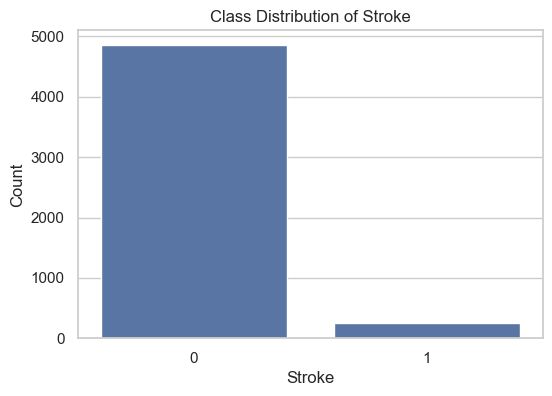

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Class Distribution of Stroke")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [15]:
numerical_features = ["age", "avg_glucose_level", "bmi"]

stroke_group_summary = df.groupby("stroke")[numerical_features].agg(["mean", "median", "std"])
display(stroke_group_summary)

age                   avg_glucose_level                            bmi                 
             mean median        std              mean   median        std       mean median       std
stroke                                                                                               
0       41.974831   43.0  22.293056        104.787584   91.465  43.847095  28.824431   28.0  7.908573
1       67.728193   71.0  12.727419        132.544739  105.220  61.921056  30.471292   29.7  6.329452

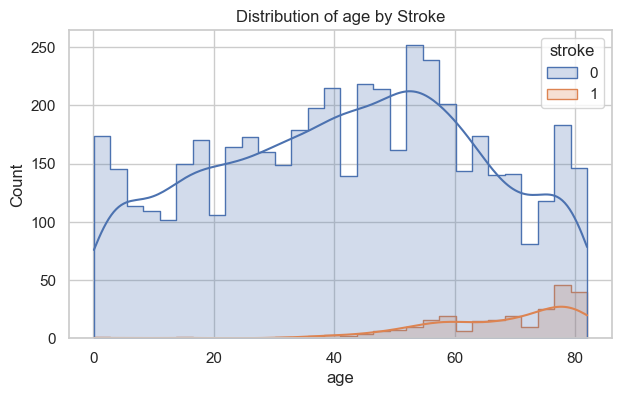

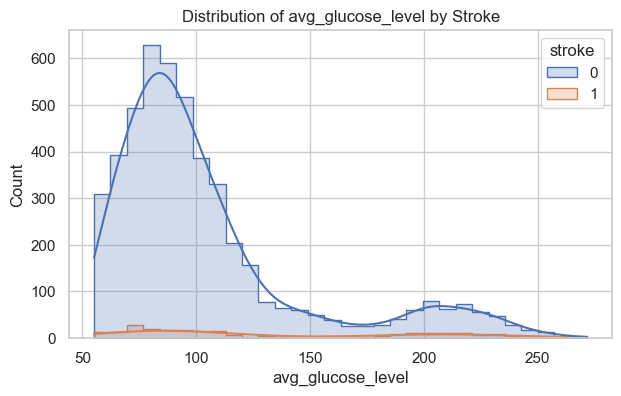

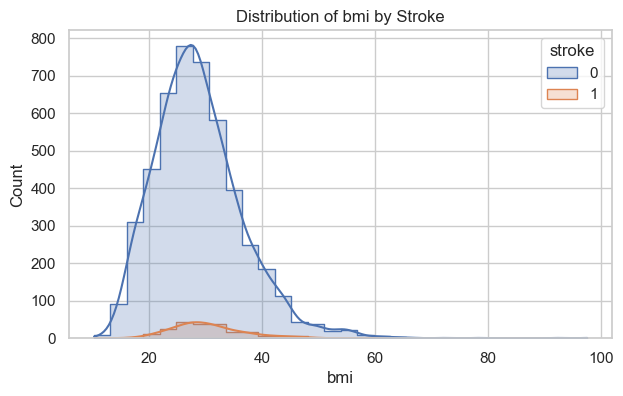

In [16]:
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="stroke", kde=True, bins=30, element="step")
    plt.title(f"Distribution of {col} by Stroke")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

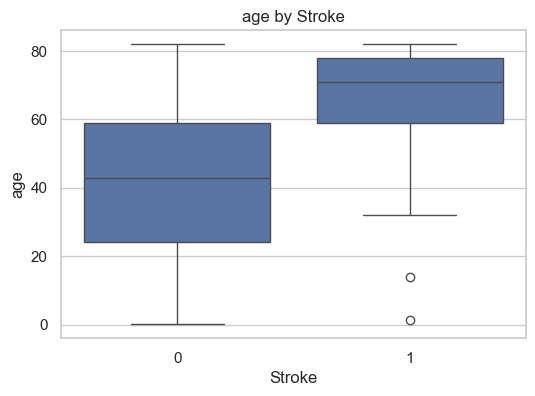

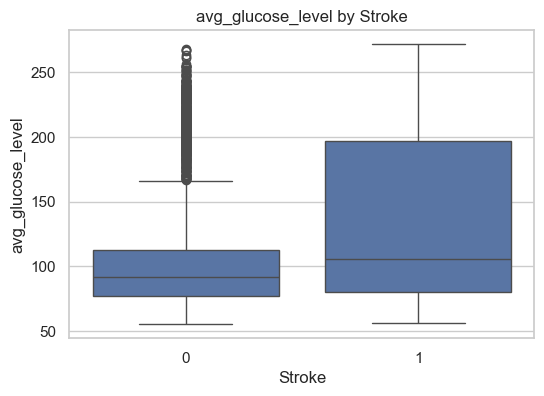

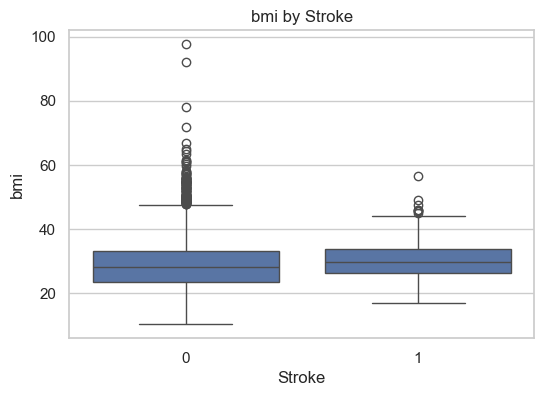

In [17]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} by Stroke")
    plt.xlabel("Stroke")
    plt.ylabel(col)
    plt.show()

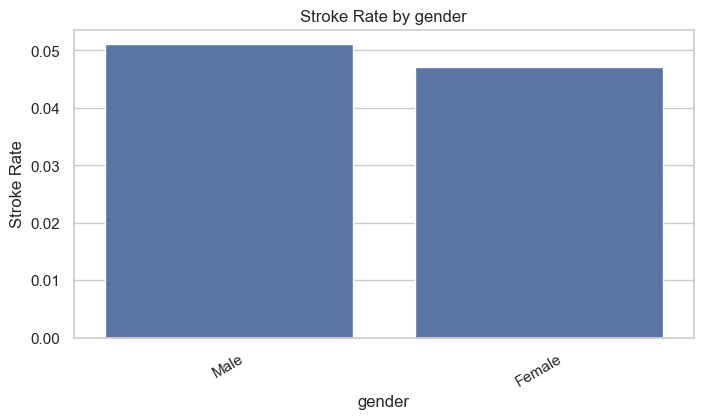

,gender,stroke
0,Male,0.051064
1,Female,0.047094


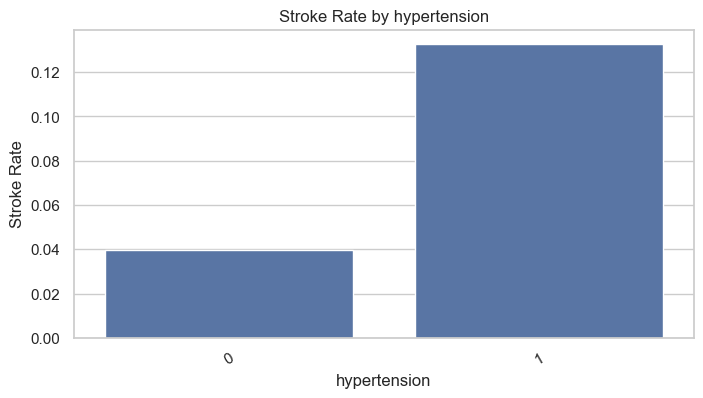

,hypertension,stroke
0,1,0.132530
1,0,0.039688


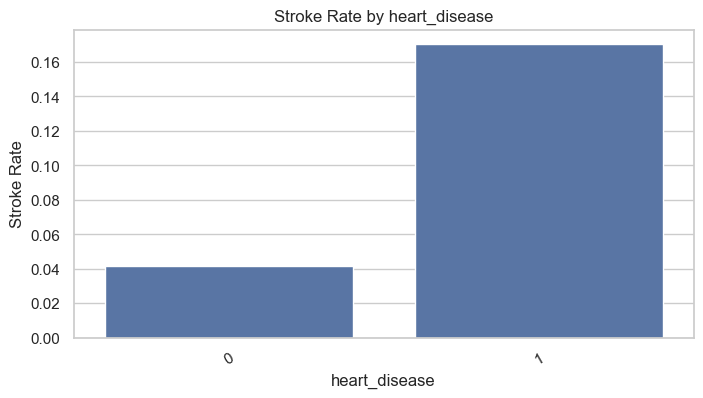

,heart_disease,stroke
0,1,0.170290
1,0,0.041796


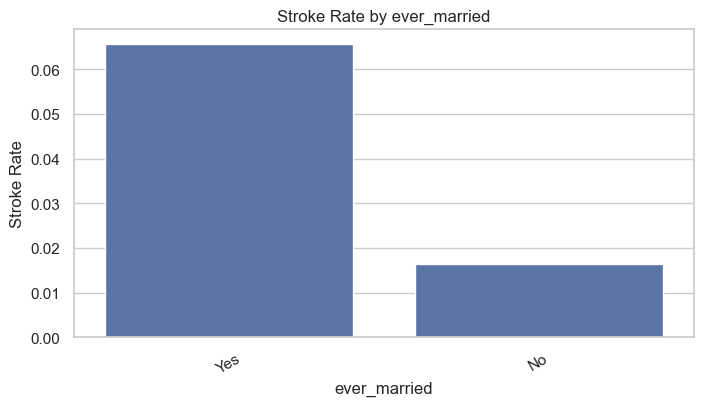

,ever_married,stroke
0,Yes,0.065613
1,No,0.016515


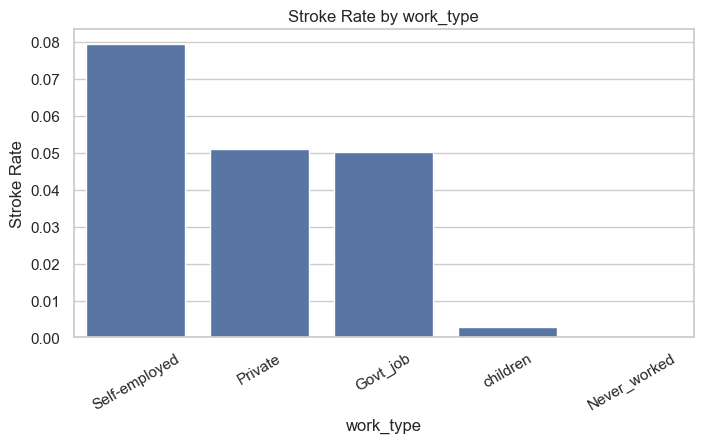

,work_type,stroke
0,Self-employed,0.079365
1,Private,0.050958
2,Govt_job,0.050228
3,children,0.002911
4,Never_worked,0.000000


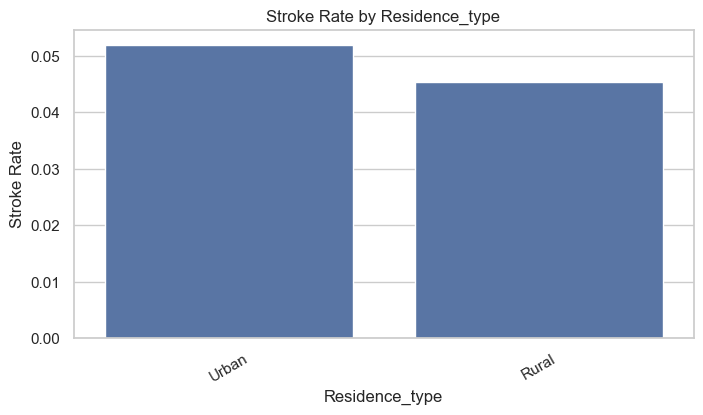

,Residence_type,stroke
0,Urban,0.052003
1,Rural,0.045364


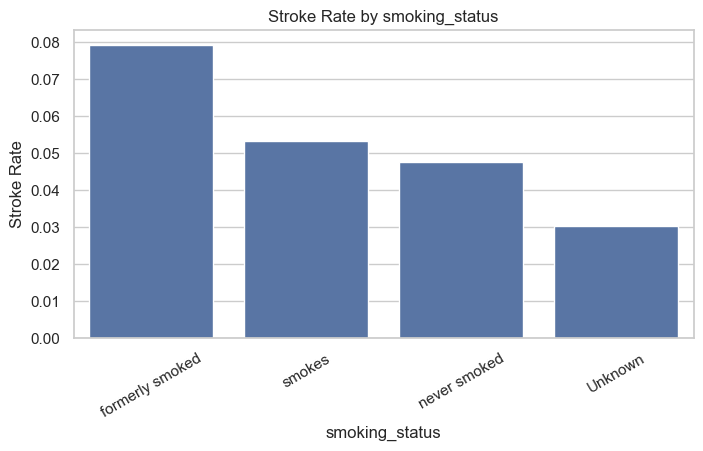

,smoking_status,stroke
0,formerly smoked,0.079186
1,smokes,0.053232
2,never smoked,0.047569
3,Unknown,0.030440


In [18]:
categorical_features = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for col in categorical_features:
    stroke_rate = (
        df.groupby(col)["stroke"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=stroke_rate, x=col, y="stroke")
    plt.title(f"Stroke Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Stroke Rate")
    plt.xticks(rotation=30)
    plt.show()

    display(stroke_rate)

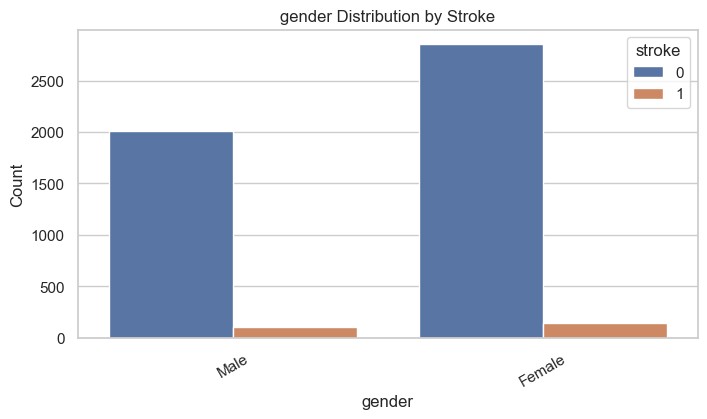

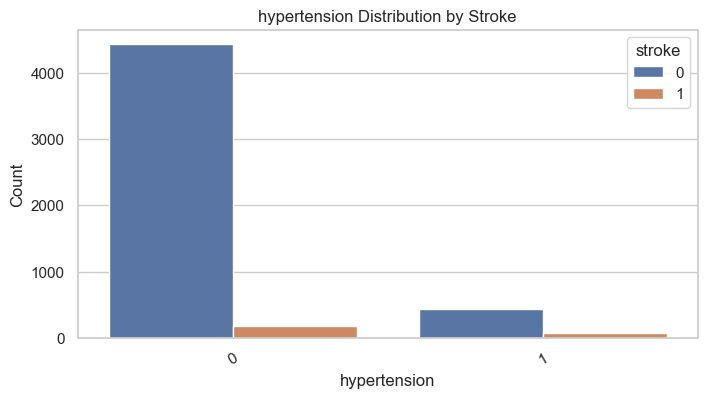

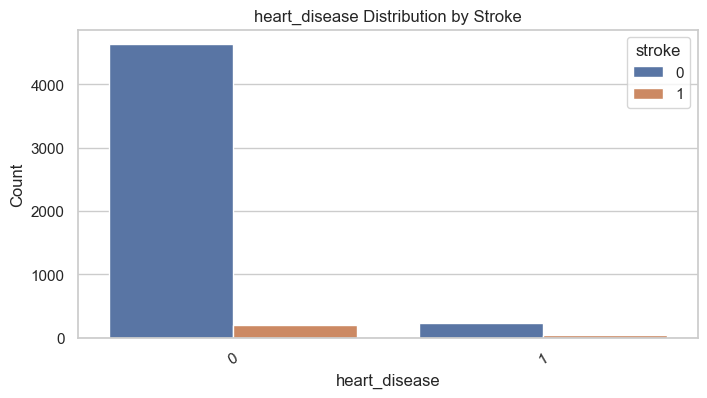

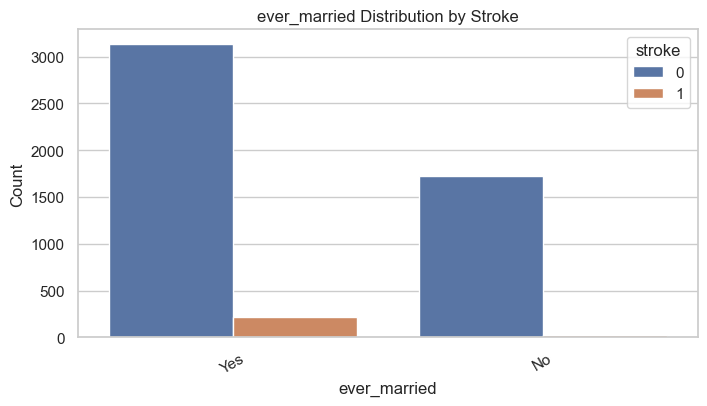

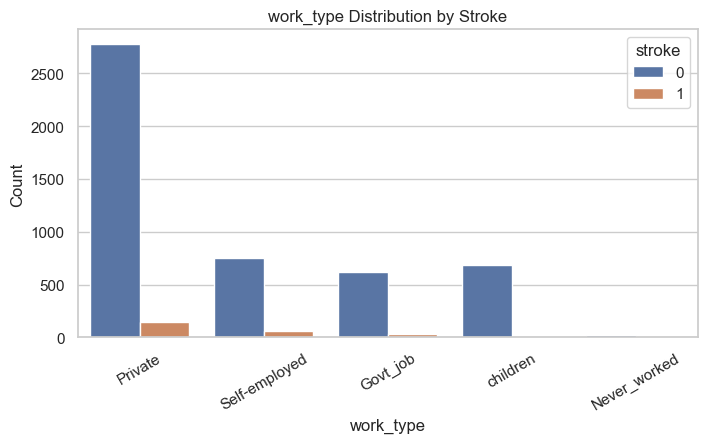

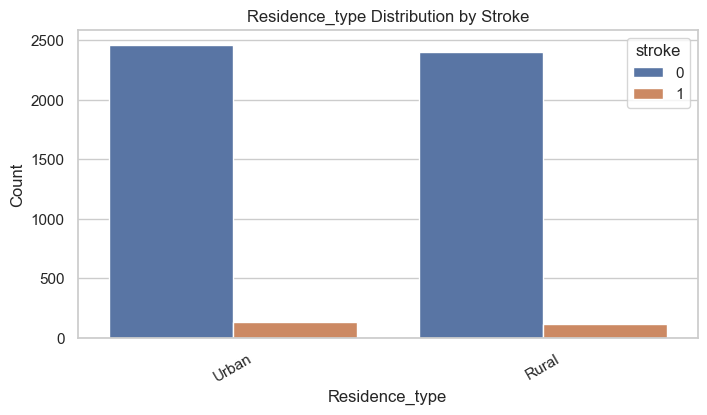

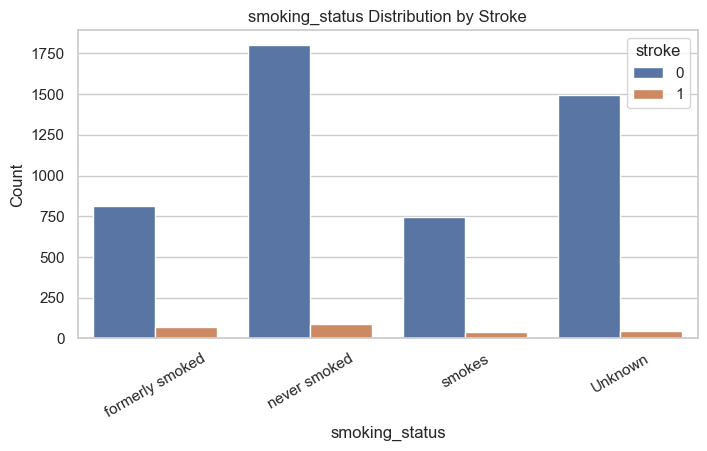

In [19]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="stroke")
    plt.title(f"{col} Distribution by Stroke")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

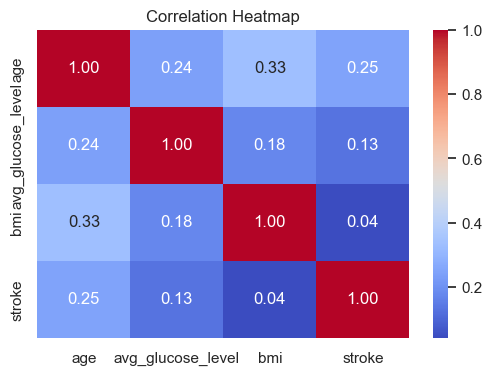

In [20]:
plt.figure(figsize=(6, 4))
corr = df[numerical_features + ["stroke"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
# Age group analysis
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 40, 60, 100],
    labels=['0-18', '18-40', '40-60', '60+']
)
age_group_stats = (
    df.groupby('age_group', observed=True)['stroke']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'stroke_rate'})
    .reset_index()
)

display(age_group_stats)

,age_group,count,stroke_rate
0,0-18,916,0.002183
1,18-40,1327,0.004521
2,40-60,1562,0.040973
3,60+,1304,0.135736


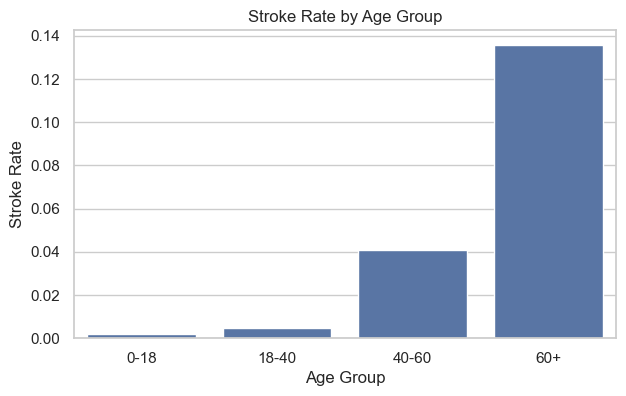

In [22]:
plt.figure(figsize=(7, 4))
sns.barplot(data=age_group_stats, x='age_group', y='stroke_rate')
plt.title("Stroke Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate")
plt.show()

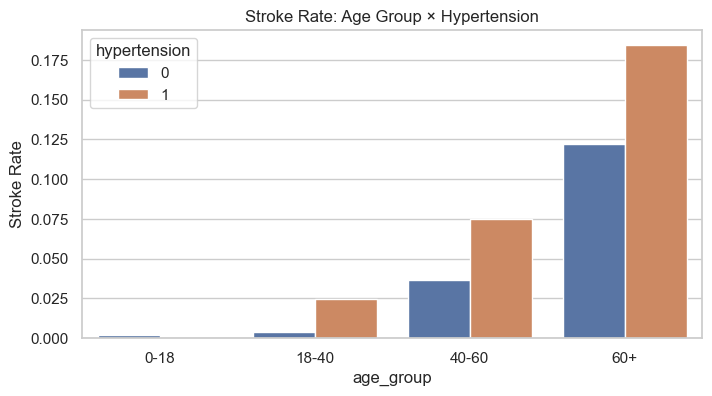

,age_group,hypertension,stroke
0,0-18,0,0.002186
1,0-18,1,0.000000
2,18-40,0,0.003888
3,18-40,1,0.024390
4,40-60,0,0.036744
5,40-60,1,0.074713
6,60+,0,0.122309
7,60+,1,0.184397


In [23]:
# Interaction analysis
interaction_ht = (
    df.groupby(['age_group', 'hypertension'], observed=True)['stroke']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=interaction_ht, x='age_group', y='stroke', hue='hypertension')
plt.title("Stroke Rate: Age Group × Hypertension")
plt.ylabel("Stroke Rate")
plt.show()

display(interaction_ht)

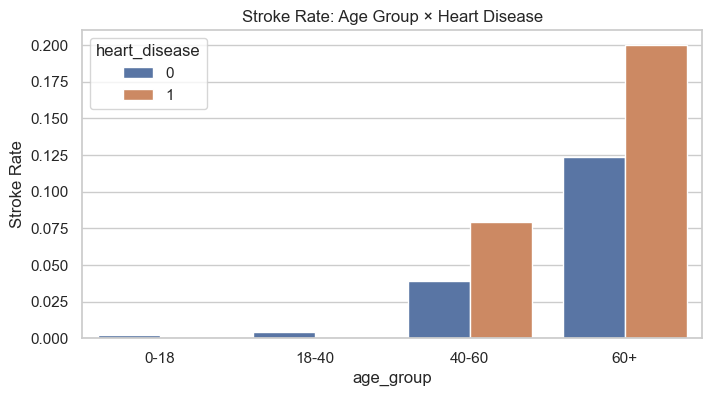

,age_group,heart_disease,stroke
0,0-18,0,0.002186
1,0-18,1,0.000000
2,18-40,0,0.004528
3,18-40,1,0.000000
4,40-60,0,0.039360
5,40-60,1,0.079365
6,60+,0,0.123400
7,60+,1,0.200000


In [24]:
interaction_hd = (
    df.groupby(['age_group', 'heart_disease'], observed=False)['stroke']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=interaction_hd, x='age_group', y='stroke', hue='heart_disease')
plt.title("Stroke Rate: Age Group × Heart Disease")
plt.ylabel("Stroke Rate")
plt.show()

display(interaction_hd)

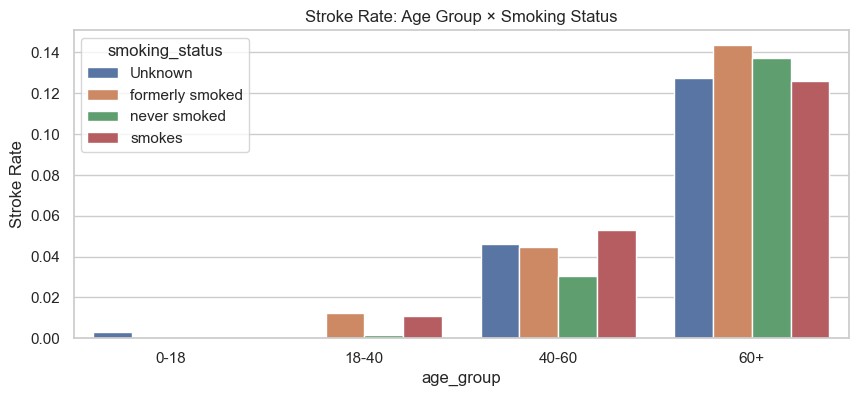

,age_group,smoking_status,stroke
0,0-18,Unknown,0.002821
1,0-18,formerly smoked,0.000000
2,0-18,never smoked,0.000000
3,0-18,smokes,0.000000
4,18-40,Unknown,0.000000
5,18-40,formerly smoked,0.012121
6,18-40,never smoked,0.001684
7,18-40,smokes,0.010714
8,40-60,Unknown,0.046053
9,40-60,formerly smoked,0.044444


In [25]:
interaction_smoking = (
    df.groupby(['age_group', 'smoking_status'], observed=False)['stroke']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=interaction_smoking, x='age_group', y='stroke', hue='smoking_status')
plt.title("Stroke Rate: Age Group × Smoking Status")
plt.ylabel("Stroke Rate")
plt.show()

display(interaction_smoking)

In [26]:
# BMI missing analysis
df['bmi_missing'] = df['bmi'].isna()

bmi_missing_stats = (
    df.groupby('bmi_missing')['stroke']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'stroke_rate'})
    .reset_index()
)

display(bmi_missing_stats)

,bmi_missing,count,stroke_rate
0,False,4908,0.042584
1,True,201,0.199005


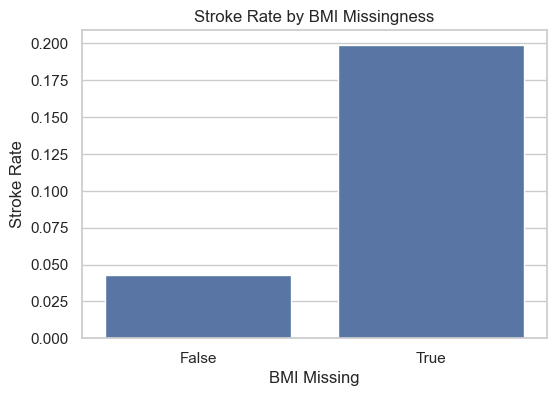

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(data=bmi_missing_stats, x='bmi_missing', y='stroke_rate')
plt.title("Stroke Rate by BMI Missingness")
plt.xlabel("BMI Missing")
plt.ylabel("Stroke Rate")
plt.show()

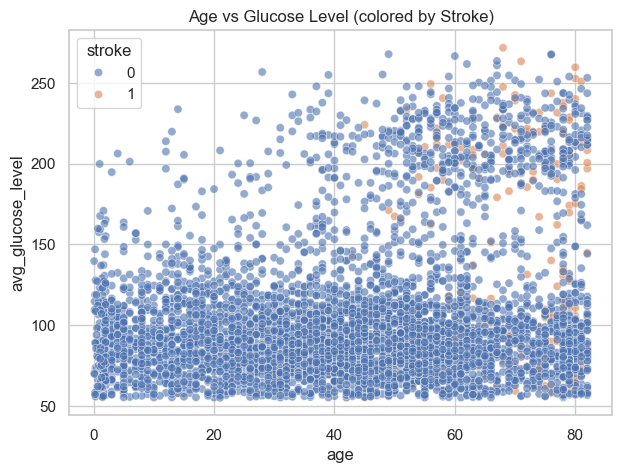

In [28]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    hue='stroke',
    alpha=0.6
)
plt.title("Age vs Glucose Level (colored by Stroke)")
plt.show()

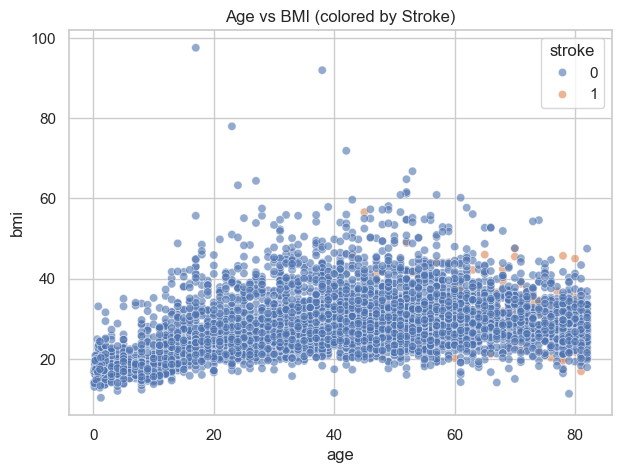

In [29]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='age',
    y='bmi',
    hue='stroke',
    alpha=0.6
)
plt.title("Age vs BMI (colored by Stroke)")
plt.show()

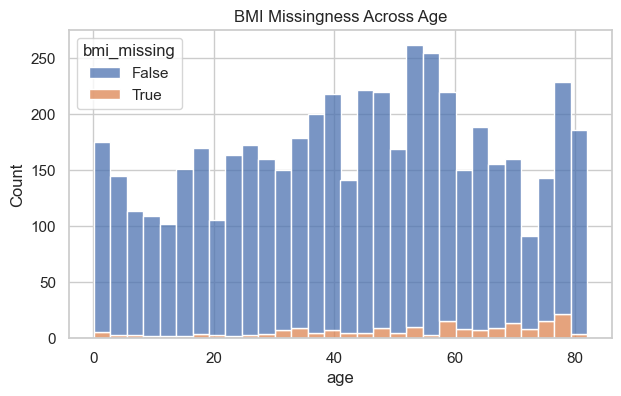

In [30]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='age', hue='bmi_missing', bins=30, multiple='stack')
plt.title("BMI Missingness Across Age")
plt.show()

In [31]:
bmi_age_interaction = (
    df.groupby(['age_group', 'bmi_missing'], observed=False)['stroke']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'stroke_rate'})
    .reset_index()
)

display(bmi_age_interaction)

,age_group,bmi_missing,count,stroke_rate
0,0-18,False,895,0.001117
1,0-18,True,21,0.047619
2,18-40,False,1288,0.003882
3,18-40,True,39,0.025641
4,40-60,False,1508,0.037798
5,40-60,True,54,0.129630
6,60+,False,1217,0.119967
7,60+,True,87,0.356322


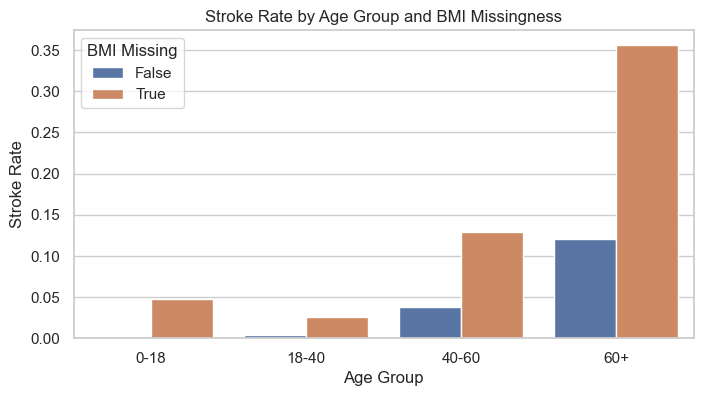

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=bmi_age_interaction,
    x='age_group',
    y='stroke_rate',
    hue='bmi_missing'
)

plt.title("Stroke Rate by Age Group and BMI Missingness")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate")
plt.legend(title="BMI Missing")
plt.show()

In [33]:
pivot_table = bmi_age_interaction.pivot(
    index='age_group',
    columns='bmi_missing',
    values='stroke_rate'
)

display(pivot_table)

bmi_missing,False,True
age_group,,
0-18,0.001117,0.047619
18-40,0.003882,0.025641
40-60,0.037798,0.129630
60+,0.119967,0.356322


In [34]:
features = [
    'age',
    'avg_glucose_level',
    'hypertension',
    'heart_disease'
]

X = df[features].copy()

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

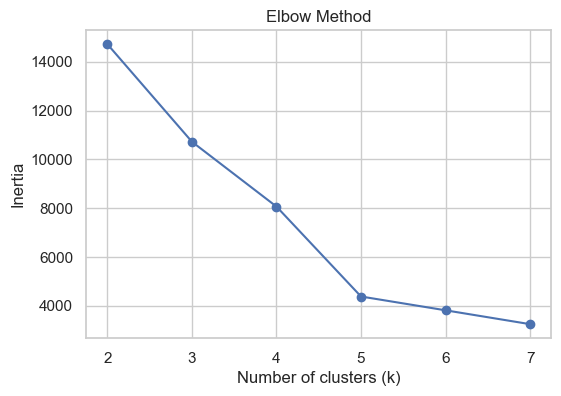

In [36]:
inertia = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [38]:
df['cluster'].value_counts().sort_index()

cluster
0    1991
1     434
2     467
3    1941
4     276
Name: count, dtype: int64

In [39]:
cluster_summary = df.groupby('cluster')[features].mean()
display(cluster_summary)

,age,avg_glucose_level,hypertension,heart_disease
cluster,,,,
0,56.200904,89.098182,0.000000,0.0
1,61.016129,127.089562,1.000000,0.0
2,55.629550,202.865353,0.000000,0.0
3,19.415765,91.303375,0.000000,0.0
4,68.188406,136.818768,0.231884,1.0


In [40]:
cluster_age = df.groupby(['cluster', 'age_group'], observed=False).size().unstack()
display(cluster_age)

age_group,0-18,18-40,40-60,60+
cluster,,,,
0,0,160,1160,671
1,1,41,163,229
2,14,83,176,194
3,900,1041,0,0
4,1,2,63,210


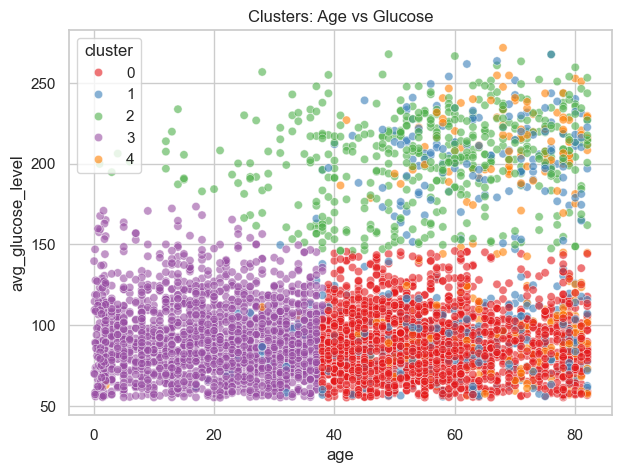

In [41]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    hue='cluster',
    palette='Set1',
    alpha=0.6
)
plt.title("Clusters: Age vs Glucose")
plt.show()

In [42]:
df.groupby('cluster')['bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,1943.0,30.113587,6.679810,11.3,25.6,29.2,33.500,66.8
1,393.0,33.280916,9.043874,15.0,27.7,31.9,36.800,97.6
2,427.0,33.047775,7.876185,14.2,27.3,31.9,37.500,71.9
3,1902.0,25.628864,7.682937,10.3,20.1,24.2,29.475,64.4
4,243.0,30.316461,5.290212,19.1,26.7,29.8,33.000,54.7


In [43]:
cluster_bmi_median = df.groupby('cluster')['bmi'].median()
print(cluster_bmi_median)

cluster
0    29.2
1    31.9
2    31.9
3    24.2
4    29.8
Name: bmi, dtype: float64


In [44]:
df['bmi_imputed'] = df['bmi']

df['bmi_imputed'] = df.apply(
    lambda row: cluster_bmi_median[row['cluster']] if pd.isna(row['bmi']) else row['bmi'],
    axis=1
)
df['bmi_imputed'].isna().sum()

0

In [45]:
df.groupby('cluster')['bmi_imputed'].mean()

cluster
0    30.091562
1    33.150461
2    32.949465
3    25.600155
4    30.254710
Name: bmi_imputed, dtype: float64

In [46]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_missing,cluster,bmi_imputed
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,60+,False,4,36.6
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,60+,True,2,31.9
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,60+,False,4,32.5
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,40-60,False,2,34.4
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,60+,False,1,24.0


In [47]:
print("Columns:")
for col in df.columns:
    print(f"- {col}")

Columns:
- gender
- age
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- avg_glucose_level
- bmi
- smoking_status
- stroke
- age_group
- bmi_missing
- cluster
- bmi_imputed


# 3. Preprocessing

In [48]:
features_A = [
    'age',
    'avg_glucose_level',
    'bmi_imputed',
    'hypertension',
    'heart_disease',
    'work_type',
    'smoking_status'
]

features_B = features_A + ['bmi_missing']

target = 'stroke'


df_A = df[features_A + [target]].copy()
df_B = df[features_B + [target]].copy()

print("Dataset A shape:", df_A.shape)
print("Dataset B shape:", df_B.shape)

Dataset A shape: (5109, 8)
Dataset B shape: (5109, 9)


In [49]:
X_A = df_A.drop(columns=[target])
y_A = df_A[target]

X_B = df_B.drop(columns=[target])
y_B = df_B[target]

In [50]:
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y_A,
    test_size=0.2,
    random_state=42,
    stratify=y_A
)

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B,
    test_size=0.2,
    random_state=42,
    stratify=y_B
)

print("A train/test:", X_A_train.shape, X_A_test.shape)
print("B train/test:", X_B_train.shape, X_B_test.shape)

A train/test: (4087, 7) (1022, 7)
B train/test: (4087, 8) (1022, 8)


In [51]:
categorical_cols_A = [
    'work_type',
    'smoking_status'
]

numerical_cols_A = [
    'age',
    'avg_glucose_level',
    'bmi_imputed',
    'hypertension',
    'heart_disease'
]

categorical_cols_B = [
    'work_type',
    'smoking_status'
]

numerical_cols_B = [
    'age',
    'avg_glucose_level',
    'bmi_imputed',
    'hypertension',
    'heart_disease',
    'bmi_missing'
]

In [52]:
preprocessor_A = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_A),
        ('num', 'passthrough', numerical_cols_A)
    ]
)

preprocessor_B = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_B),
        ('num', 'passthrough', numerical_cols_B)
    ]
)

In [53]:
X_A_train_processed = preprocessor_A.fit_transform(X_A_train)
X_A_test_processed = preprocessor_A.transform(X_A_test)

X_B_train_processed = preprocessor_B.fit_transform(X_B_train)
X_B_test_processed = preprocessor_B.transform(X_B_test)

print("Processed A train/test:", X_A_train_processed.shape, X_A_test_processed.shape)
print("Processed B train/test:", X_B_train_processed.shape, X_B_test_processed.shape)

Processed A train/test: (4087, 14) (1022, 14)
Processed B train/test: (4087, 15) (1022, 15)


In [54]:
feature_names_A = preprocessor_A.get_feature_names_out()
feature_names_B = preprocessor_B.get_feature_names_out()

print("Dataset A features:")
print(feature_names_A)

print("\nDataset B features:")
print(feature_names_B)

Dataset A features:
['cat__work_type_Govt_job' 'cat__work_type_Never_worked'
 'cat__work_type_Private' 'cat__work_type_Self-employed'
 'cat__work_type_children' 'cat__smoking_status_Unknown'
 'cat__smoking_status_formerly smoked' 'cat__smoking_status_never smoked'
 'cat__smoking_status_smokes' 'num__age' 'num__avg_glucose_level'
 'num__bmi_imputed' 'num__hypertension' 'num__heart_disease']

Dataset B features:
['cat__work_type_Govt_job' 'cat__work_type_Never_worked'
 'cat__work_type_Private' 'cat__work_type_Self-employed'
 'cat__work_type_children' 'cat__smoking_status_Unknown'
 'cat__smoking_status_formerly smoked' 'cat__smoking_status_never smoked'
 'cat__smoking_status_smokes' 'num__age' 'num__avg_glucose_level'
 'num__bmi_imputed' 'num__hypertension' 'num__heart_disease'
 'num__bmi_missing']


In [55]:
X = X_A_train_processed
y = y_A_train

In [56]:
X = sm.add_constant(X)

In [57]:
model = sm.Logit(y, X)
result = model.fit_regularized()

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.15512305177145816
            Iterations: 140
            Function evaluations: 150
            Gradient evaluations: 140


In [58]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4087
Model:                          Logit   Df Residuals:                     4072
Method:                           MLE   Df Model:                           14
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.2030
Time:                        11:40:22   Log-Likelihood:                -633.99
converged:                       True   LL-Null:                       -795.50
Covariance Type:            nonrobust   LLR p-value:                 1.830e-60
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.2222   4.17e+06  -2.93e-06      1.000   -8.17e+06    8.17e+06
x1             5.2853        nan        nan        nan         nan         nan
x2           -10.5876        nan        nan        n

In [59]:
feature_names_A = preprocessor_A.get_feature_names_out()

In [60]:
coef_df = pd.DataFrame({
    "feature": feature_names_A,
    "coef": result.params[1:],
    "p_value": result.pvalues[1:]
})

# Sort by significance
coef_df = coef_df.sort_values(by="p_value")

print(coef_df.head(15))

                                 feature       coef       p_value
x10                             num__age   0.073059  1.957171e-29
x11               num__avg_glucose_level   0.003985  2.824525e-03
x13                    num__hypertension   0.505888  5.717739e-03
x14                   num__heart_disease   0.164007  4.413917e-01
x12                     num__bmi_imputed   0.006627  5.944231e-01
x1               cat__work_type_Govt_job   5.285301           NaN
x2           cat__work_type_Never_worked -10.587645           NaN
x3                cat__work_type_Private   5.310939           NaN
x4          cat__work_type_Self-employed   5.046331           NaN
x5               cat__work_type_children   5.789052           NaN
x6           cat__smoking_status_Unknown  -0.947326           NaN
x7   cat__smoking_status_formerly smoked  -0.879088           NaN
x8      cat__smoking_status_never smoked  -1.104654           NaN
x9            cat__smoking_status_smokes  -0.757901           NaN


In [61]:
significant = coef_df[coef_df["p_value"] < 0.05]
print(significant)

                    feature      coef       p_value
x10                num__age  0.073059  1.957171e-29
x11  num__avg_glucose_level  0.003985  2.824525e-03
x13       num__hypertension  0.505888  5.717739e-03


# Logistic Regression

In [62]:
# Logistic Regression preprocessors
lr_preprocessor_A = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_A),
        ('num', StandardScaler(), numerical_cols_A)
    ]
)

lr_preprocessor_B = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_B),
        ('num', StandardScaler(), numerical_cols_B)
    ]
)

In [63]:
lr_pipeline_A = Pipeline([
    ('preprocessing', lr_preprocessor_A),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

lr_pipeline_B = Pipeline([
    ('preprocessing', lr_preprocessor_B),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

In [64]:
lr_pipeline_A.fit(X_A_train, y_A_train)
lr_pipeline_B.fit(X_B_train, y_B_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_type',
                                                   'smoking_status']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi_imputed',
                                                   'hypertension',
                                                   'heart_disease',
                                                   'bmi_missing'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [65]:
y_A_pred = lr_pipeline_A.predict(X_A_test)
y_B_pred = lr_pipeline_B.predict(X_B_test)

y_A_proba = lr_pipeline_A.predict_proba(X_A_test)[:, 1]
y_B_proba = lr_pipeline_B.predict_proba(X_B_test)[:, 1]

In [66]:
print("=== Logistic Regression: Dataset A (without bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_A_test, y_A_pred))
print("\nClassification Report:")
print(classification_report(y_A_test, y_A_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba))

print("\n" + "="*60 + "\n")

print("=== Logistic Regression: Dataset B (with bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_B_pred))
print("\nClassification Report:")
print(classification_report(y_B_test, y_B_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_B_proba))
print("PR-AUC:", average_precision_score(y_B_test, y_B_proba))

=== Logistic Regression: Dataset A (without bmi_missing) ===
Confusion Matrix:
[[707 265]
 [  9  41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9874    0.7274    0.8377       972
           1     0.1340    0.8200    0.2303        50

    accuracy                         0.7319      1022
   macro avg     0.5607    0.7737    0.5340      1022
weighted avg     0.9457    0.7319    0.8080      1022

ROC-AUC: 0.8426954732510288
PR-AUC: 0.2545676377254629


=== Logistic Regression: Dataset B (with bmi_missing) ===
Confusion Matrix:
[[735 237]
 [ 10  40]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9866    0.7562    0.8561       972
           1     0.1444    0.8000    0.2446        50

    accuracy                         0.7583      1022
   macro avg     0.5655    0.7781    0.5504      1022
weighted avg     0.9454    0.7583    0.8262      1022

ROC-AUC: 0.8385390946502057
PR-AUC: 0.22

PR-AUC (Dataset A): 0.2545676377254629
PR-AUC (Dataset B): 0.2225602016239057


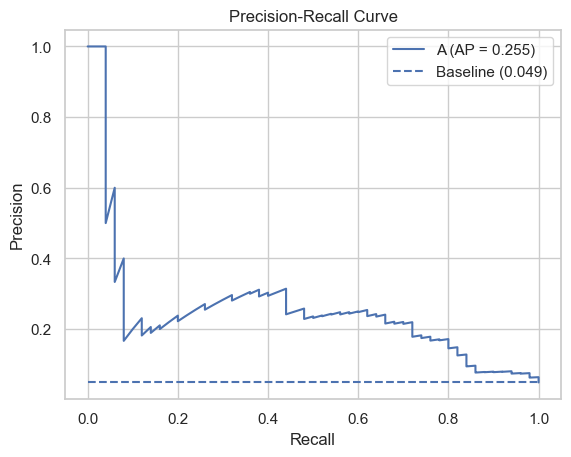

In [67]:
# Dataset A
precision_A, recall_A, _ = precision_recall_curve(y_A_test, y_A_proba)
pr_auc_A = average_precision_score(y_A_test, y_A_proba)

# Dataset B
precision_B, recall_B, _ = precision_recall_curve(y_B_test, y_B_proba)
pr_auc_B = average_precision_score(y_B_test, y_B_proba)

print("PR-AUC (Dataset A):", pr_auc_A)
print("PR-AUC (Dataset B):", pr_auc_B)

# Plot
plt.figure()
plt.plot(recall_A, precision_A, label=f"A (AP = {pr_auc_A:.3f})")

# Baseline
baseline = sum(y_A_test) / len(y_A_test)
plt.hlines(baseline, 0, 1, linestyles='dashed', label=f'Baseline ({baseline:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [68]:
thresholds = np.linspace(0, 1, 200)

best = []

for t in thresholds:
    y_pred = (y_A_proba >= t).astype(int)
    tp = ((y_pred == 1) & (y_A_test == 1)).sum()
    fp = ((y_pred == 1) & (y_A_test == 0)).sum()
    fn = ((y_pred == 0) & (y_A_test == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if 0.7 <= recall <= 0.8:
        best.append((t, precision, recall))

sorted(best, key=lambda x: -x[1])[:5]

[(0.7236180904522613, 0.21951219512195122, 0.72),
 (0.7286432160804021, 0.21875, 0.7),
 (0.7185929648241206, 0.21686746987951808, 0.72),
 (0.7135678391959799, 0.21176470588235294, 0.72),
 (0.7085427135678392, 0.21052631578947367, 0.72)]

In [69]:
# Using best threshold from above
threshold = 0.7236180904522613



y_A_proba = lr_pipeline_A.predict_proba(X_A_test)[:, 1]

# Setting our new threshold
y_A_pred_custom = (y_A_proba >= threshold).astype(int)

print("=== Logistic Regression: Dataset A (custom threshold) ===")
print(f"Threshold: {threshold:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_A_test, y_A_pred_custom))

print("\nClassification Report:")
print(classification_report(y_A_test, y_A_pred_custom, digits=4))

print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba))

=== Logistic Regression: Dataset A (custom threshold) ===
Threshold: 0.724

Confusion Matrix:
[[844 128]
 [ 14  36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9837    0.8683    0.9224       972
           1     0.2195    0.7200    0.3364        50

    accuracy                         0.8611      1022
   macro avg     0.6016    0.7942    0.6294      1022
weighted avg     0.9463    0.8611    0.8937      1022

ROC-AUC: 0.8426954732510288
PR-AUC: 0.2545676377254629


# Random Forests

In [70]:
rf_pipeline_A = Pipeline([
    ('preprocessing', preprocessor_A),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_B = Pipeline([
    ('preprocessing', preprocessor_B),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

In [71]:
rf_pipeline_A.fit(X_A_train, y_A_train)
rf_pipeline_B.fit(X_B_train, y_B_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_type',
                                                   'smoking_status']),
                                                 ('num', 'passthrough',
                                                  ['age', 'avg_glucose_level',
                                                   'bmi_imputed',
                                                   'hypertension',
                                                   'heart_disease',
                                                   'bmi_missing'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=8, min_samples_leaf=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [72]:
y_A_pred_rf = rf_pipeline_A.predict(X_A_test)
y_B_pred_rf = rf_pipeline_B.predict(X_B_test)

y_A_proba_rf = rf_pipeline_A.predict_proba(X_A_test)[:, 1]
y_B_proba_rf = rf_pipeline_B.predict_proba(X_B_test)[:, 1]

In [73]:
print("=== Random Forest: Dataset A (without bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_A_test, y_A_pred_rf))
print("\nClassification Report:")
print(classification_report(y_A_test, y_A_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba_rf))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba_rf))

print("\n" + "="*60 + "\n")

print("=== Random Forest: Dataset B (with bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_B_pred_rf))
print("\nClassification Report:")
print(classification_report(y_B_test, y_B_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_B_proba_rf))
print("PR-AUC:", average_precision_score(y_B_test, y_B_proba_rf))

=== Random Forest: Dataset A (without bmi_missing) ===
Confusion Matrix:
[[781 191]
 [ 14  36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9824    0.8035    0.8840       972
           1     0.1586    0.7200    0.2599        50

    accuracy                         0.7994      1022
   macro avg     0.5705    0.7617    0.5720      1022
weighted avg     0.9421    0.7994    0.8535      1022

ROC-AUC: 0.8288888888888889
PR-AUC: 0.24082517533764902


=== Random Forest: Dataset B (with bmi_missing) ===
Confusion Matrix:
[[790 182]
 [ 14  36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9826    0.8128    0.8896       972
           1     0.1651    0.7200    0.2687        50

    accuracy                         0.8082      1022
   macro avg     0.5739    0.7664    0.5791      1022
weighted avg     0.9426    0.8082    0.8593      1022

ROC-AUC: 0.8234567901234567
PR-AUC: 0.2305268725804

In [74]:
thresholds = np.arange(0.05, 0.6, 0.05)

results = []

for t in thresholds:
    y_pred = (y_A_proba_rf > t).astype(int)

    precision = precision_score(y_A_test, y_pred, zero_division=0)
    recall = recall_score(y_A_test, y_pred)
    f1 = f1_score(y_A_test, y_pred)

    results.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

rf_threshold_df = pd.DataFrame(results)
display(rf_threshold_df)

,threshold,precision,recall,f1
0,0.05,0.060345,0.98,0.113689
1,0.10,0.079861,0.92,0.146965
2,0.15,0.087475,0.88,0.159132
3,0.20,0.087683,0.84,0.158790
4,0.25,0.093541,0.84,0.168337
5,0.30,0.099291,0.84,0.177590
6,0.35,0.109661,0.84,0.193995
7,0.40,0.120235,0.82,0.209719
8,0.45,0.138889,0.80,0.236686
9,0.50,0.158590,0.72,0.259928


In [75]:
results_B = []

for t in thresholds:
    y_pred = (y_B_proba_rf > t).astype(int)

    precision = precision_score(y_B_test, y_pred, zero_division=0)
    recall = recall_score(y_B_test, y_pred)
    f1 = f1_score(y_B_test, y_pred)

    results_B.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

rf_threshold_df_B = pd.DataFrame(results_B)
display(rf_threshold_df_B)

,threshold,precision,recall,f1
0,0.05,0.056243,1.00,0.106496
1,0.10,0.076923,0.92,0.141975
2,0.15,0.085714,0.90,0.156522
3,0.20,0.086694,0.86,0.157509
4,0.25,0.092077,0.86,0.166344
5,0.30,0.095672,0.84,0.171779
6,0.35,0.107417,0.84,0.190476
7,0.40,0.117479,0.82,0.205514
8,0.45,0.137809,0.78,0.234234
9,0.50,0.165138,0.72,0.268657


In [76]:
threshold = 0.45
y_A_pred_rf_adj = (y_A_proba_rf > threshold).astype(int)
y_B_pred_rf_adj = (y_B_proba_rf > threshold).astype(int)

print("=== Random Forest (Adjusted Threshold): Dataset A ===")
print("Confusion Matrix:")
print(confusion_matrix(y_A_test, y_A_pred_rf_adj))
print("\nClassification Report:")
print(classification_report(y_A_test, y_A_pred_rf_adj, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba_rf))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba_rf))

print("\n" + "="*60 + "\n")

print("=== Random Forest (Adjusted Threshold): Dataset B ===")
print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_B_pred_rf_adj))
print("\nClassification Report:")
print(classification_report(y_B_test, y_B_pred_rf_adj, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_B_proba_rf))
print("PR-AUC:", average_precision_score(y_B_test, y_B_proba_rf))

=== Random Forest (Adjusted Threshold): Dataset A ===
Confusion Matrix:
[[724 248]
 [ 10  40]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9864    0.7449    0.8488       972
           1     0.1389    0.8000    0.2367        50

    accuracy                         0.7476      1022
   macro avg     0.5626    0.7724    0.5427      1022
weighted avg     0.9449    0.7476    0.8188      1022

ROC-AUC: 0.8288888888888889
PR-AUC: 0.24082517533764902


=== Random Forest (Adjusted Threshold): Dataset B ===
Confusion Matrix:
[[728 244]
 [ 11  39]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9851    0.7490    0.8510       972
           1     0.1378    0.7800    0.2342        50

    accuracy                         0.7505      1022
   macro avg     0.5615    0.7645    0.5426      1022
weighted avg     0.9437    0.7505    0.8208      1022

ROC-AUC: 0.8234567901234567
PR-AUC: 0.230526872580

# Gradient Boosting

In [77]:
gb_pipeline_A = Pipeline([
    ('preprocessing', preprocessor_A),
    ('model', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        class_weight='balanced',
        random_state=42
    ))
])

gb_pipeline_B = Pipeline([
    ('preprocessing', preprocessor_B),
    ('model', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        class_weight='balanced',
        random_state=42
    ))
])

In [78]:
gb_pipeline_A.fit(X_A_train, y_A_train)
gb_pipeline_B.fit(X_B_train, y_B_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_type',
                                                   'smoking_status']),
                                                 ('num', 'passthrough',
                                                  ['age', 'avg_glucose_level',
                                                   'bmi_imputed',
                                                   'hypertension',
                                                   'heart_disease',
                                                   'bmi_missing'])])),
                ('model',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                learning_rate=0.05, max_depth=4,
                                                max_iter=200,
                                                random_state=42))])

In [79]:
y_A_pred_gb = gb_pipeline_A.predict(X_A_test)
y_B_pred_gb = gb_pipeline_B.predict(X_B_test)

y_A_proba_gb = gb_pipeline_A.predict_proba(X_A_test)[:, 1]
y_B_proba_gb = gb_pipeline_B.predict_proba(X_B_test)[:, 1]

In [80]:
print("=== Gradient Boosting: Dataset A (without bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_A_test, y_A_pred_gb))
print("\nClassification Report:")
print(classification_report(y_A_test, y_A_pred_gb, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba_gb))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba_gb))

print("\n" + "="*60 + "\n")

print("=== Gradient Boosting: Dataset B (with bmi_missing) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_B_pred_gb))
print("\nClassification Report:")
print(classification_report(y_B_test, y_B_pred_gb, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_B_proba_gb))
print("PR-AUC:", average_precision_score(y_B_test, y_B_proba_gb))

=== Gradient Boosting: Dataset A (without bmi_missing) ===
Confusion Matrix:
[[787 185]
 [ 15  35]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9813    0.8097    0.8873       972
           1     0.1591    0.7000    0.2593        50

    accuracy                         0.8043      1022
   macro avg     0.5702    0.7548    0.5733      1022
weighted avg     0.9411    0.8043    0.8565      1022

ROC-AUC: 0.8196707818930041
PR-AUC: 0.1781870566760397


=== Gradient Boosting: Dataset B (with bmi_missing) ===
Confusion Matrix:
[[785 187]
 [ 18  32]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9776    0.8076    0.8845       972
           1     0.1461    0.6400    0.2379        50

    accuracy                         0.7994      1022
   macro avg     0.5619    0.7238    0.5612      1022
weighted avg     0.9369    0.7994    0.8529      1022

ROC-AUC: 0.8168106995884774
PR-AUC: 0.200731

In [81]:


thresholds = np.arange(0.05, 0.6, 0.05)

gb_results_A = []

for t in thresholds:
    y_pred = (y_A_proba_gb > t).astype(int)

    precision = precision_score(y_A_test, y_pred, zero_division=0)
    recall = recall_score(y_A_test, y_pred)
    f1 = f1_score(y_A_test, y_pred)

    gb_results_A.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

gb_threshold_df_A = pd.DataFrame(gb_results_A)
display(gb_threshold_df_A)

,threshold,precision,recall,f1
0,0.05,0.084942,0.88,0.154930
1,0.10,0.091286,0.88,0.165414
2,0.15,0.097130,0.88,0.174950
3,0.20,0.100467,0.86,0.179916
4,0.25,0.104592,0.82,0.185520
5,0.30,0.110193,0.80,0.193705
6,0.35,0.124611,0.80,0.215633
7,0.40,0.137931,0.80,0.235294
8,0.45,0.147410,0.74,0.245847
9,0.50,0.159091,0.70,0.259259


In [82]:
gb_results_B = []

for t in thresholds:
    y_pred = (y_B_proba_gb > t).astype(int)

    precision = precision_score(y_B_test, y_pred, zero_division=0)
    recall = recall_score(y_B_test, y_pred)
    f1 = f1_score(y_B_test, y_pred)

    gb_results_B.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

gb_threshold_df_B = pd.DataFrame(gb_results_B)
display(gb_threshold_df_B)

,threshold,precision,recall,f1
0,0.05,0.087719,0.90,0.159858
1,0.10,0.093023,0.88,0.168260
2,0.15,0.093126,0.84,0.167665
3,0.20,0.095794,0.82,0.171548
4,0.25,0.107612,0.82,0.190255
5,0.30,0.116809,0.82,0.204489
6,0.35,0.122642,0.78,0.211957
7,0.40,0.135417,0.78,0.230769
8,0.45,0.140625,0.72,0.235294
9,0.50,0.146119,0.64,0.237918


In [83]:
best_threshold = 0.3

y_A_pred_gb_adj = (y_A_proba_gb > best_threshold).astype(int)
y_B_pred_gb_adj = (y_B_proba_gb > best_threshold).astype(int)

In [84]:
print("=== Gradient Boosting (Adjusted Threshold): Dataset A ===")
print(confusion_matrix(y_A_test, y_A_pred_gb_adj))
print(classification_report(y_A_test, y_A_pred_gb_adj, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_A_proba_gb))
print("PR-AUC:", average_precision_score(y_A_test, y_A_proba_gb))

print("\n" + "="*60 + "\n")

print("=== Gradient Boosting (Adjusted Threshold): Dataset B ===")
print(confusion_matrix(y_B_test, y_B_pred_gb_adj))
print(classification_report(y_B_test, y_B_pred_gb_adj, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_B_proba_gb))
print("PR-AUC:", average_precision_score(y_B_test, y_B_proba_gb))

=== Gradient Boosting (Adjusted Threshold): Dataset A ===
[[649 323]
 [ 10  40]]
              precision    recall  f1-score   support

           0     0.9848    0.6677    0.7958       972
           1     0.1102    0.8000    0.1937        50

    accuracy                         0.6742      1022
   macro avg     0.5475    0.7338    0.4948      1022
weighted avg     0.9420    0.6742    0.7664      1022

ROC-AUC: 0.8196707818930041
PR-AUC: 0.1781870566760397


=== Gradient Boosting (Adjusted Threshold): Dataset B ===
[[662 310]
 [  9  41]]
              precision    recall  f1-score   support

           0     0.9866    0.6811    0.8058       972
           1     0.1168    0.8200    0.2045        50

    accuracy                         0.6879      1022
   macro avg     0.5517    0.7505    0.5052      1022
weighted avg     0.9440    0.6879    0.7764      1022

ROC-AUC: 0.8168106995884774
PR-AUC: 0.2007310926102896


# Further Improving The Models

In [85]:
# Cross validation and scoring
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

In [86]:
lr_grid_pipeline_A = Pipeline([
    ('preprocessing', lr_preprocessor_A),
    ('model', LogisticRegression(
        random_state=42
    ))
])

lr_param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2', 'l1'],
    'model__solver': ['lbfgs'],
    'model__class_weight': ['balanced'],
    'model__max_iter': [1000, 2000, 5000]
}

lr_grid_A = GridSearchCV(
    estimator=lr_grid_pipeline_A,
    param_grid=lr_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid_A.fit(X_A_train, y_A_train)

print("Best LR params A:", lr_grid_A.best_params_)
print("Best LR CV PR-AUC A:", lr_grid_A.best_score_)

best_lr_model = lr_grid_A.best_estimator_

y_pred_lr = best_lr_model.predict(X_A_test)
y_proba_lr = best_lr_model.predict_proba(X_A_test)[:, 1]

print("=== Tuned Logistic Regression: Dataset A ===")
print(confusion_matrix(y_A_test, y_pred_lr))
print(classification_report(y_A_test, y_pred_lr, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_proba_lr))
print("PR-AUC:", average_precision_score(y_A_test, y_proba_lr))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best LR params A: {'model__C': 100, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR CV PR-AUC A: 0.190264094030158
=== Tuned Logistic Regression: Dataset A ===
[[708 264]
 [  9  41]]
              precision    recall  f1-score   support

           0     0.9874    0.7284    0.8384       972
           1     0.1344    0.8200    0.2310        50

    accuracy                         0.7329      1022
   macro avg     0.5609    0.7742    0.5347      1022
weighted avg     0.9457    0.7329    0.8087      1022

ROC-AUC: 0.8428395061728394
PR-AUC: 0.2545744006513536


In [87]:
rf_param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [5, 8, 12],
    'model__min_samples_leaf': [5, 10, 20],
    'model__max_features': ['sqrt'],
    'model__class_weight': ['balanced_subsample']
}

rf_grid_A = GridSearchCV(
    estimator=rf_pipeline_A,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid_A.fit(X_A_train, y_A_train)

print("Best RF params A:", rf_grid_A.best_params_)
print("Best RF CV PR-AUC A:", rf_grid_A.best_score_)

best_rf_model = rf_grid_A.best_estimator_

y_proba_rf = best_rf_model.predict_proba(X_A_test)[:, 1]
y_pred_rf = (y_proba_rf > 0.5).astype(int)

print("=== Tuned Random Forest: Dataset A ===")
print(confusion_matrix(y_A_test, y_pred_rf))
print(classification_report(y_A_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_A_test, y_proba_rf))
print("PR-AUC:", average_precision_score(y_A_test, y_proba_rf))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF params A: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
Best RF CV PR-AUC A: 0.18255420292728516
=== Tuned Random Forest: Dataset A ===
[[765 207]
 [ 10  40]]
              precision    recall  f1-score   support

           0     0.9871    0.7870    0.8758       972
           1     0.1619    0.8000    0.2694        50

    accuracy                         0.7877      1022
   macro avg     0.5745    0.7935    0.5726      1022
weighted avg     0.9467    0.7877    0.8461      1022

ROC-AUC: 0.8300823045267489
PR-AUC: 0.2503363060249051


In [88]:
gb_grid_pipeline_B = Pipeline([
    ('preprocessing', preprocessor_B),
    ('model', HistGradientBoostingClassifier(
        random_state=42
    ))
])

gb_param_grid = {
    'model__max_iter': [100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, None],
    'model__min_samples_leaf': [20, 50],
    'model__l2_regularization': [0.0, 0.1],
    'model__class_weight': [None, 'balanced']
}

gb_grid_B = GridSearchCV(
    estimator=gb_grid_pipeline_B,
    param_grid=gb_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid_B.fit(X_B_train, y_B_train)

print("Best GB params B:", gb_grid_B.best_params_)
print("Best GB CV PR-AUC B:", gb_grid_B.best_score_)

best_gb_model = gb_grid_B.best_estimator_

y_pred_gb = best_gb_model.predict(X_B_test)
y_proba_gb = best_gb_model.predict_proba(X_B_test)[:, 1]

print("=== Tuned Gradient Boosting: Dataset B ===")
print(confusion_matrix(y_B_test, y_pred_gb))
print(classification_report(y_B_test, y_pred_gb, digits=4))
print("ROC-AUC:", roc_auc_score(y_B_test, y_proba_gb))
print("PR-AUC:", average_precision_score(y_B_test, y_proba_gb))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best GB params B: {'model__class_weight': 'balanced', 'model__l2_regularization': 0.1, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 100, 'model__min_samples_leaf': 50}
Best GB CV PR-AUC B: 0.2400430150750362
=== Tuned Gradient Boosting: Dataset B ===
[[697 275]
 [  9  41]]
              precision    recall  f1-score   support

           0     0.9873    0.7171    0.8308       972
           1     0.1297    0.8200    0.2240        50

    accuracy                         0.7221      1022
   macro avg     0.5585    0.7685    0.5274      1022
weighted avg     0.9453    0.7221    0.8011      1022

ROC-AUC: 0.8388271604938271
PR-AUC: 0.23328505558553758


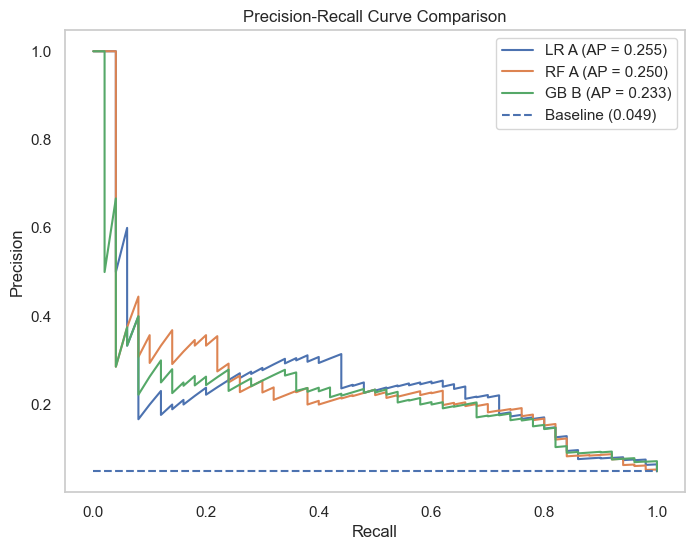

In [89]:
lr_precision, lr_recall, _ = precision_recall_curve(y_A_test, y_proba_lr)
rf_precision, rf_recall, _ = precision_recall_curve(y_A_test, y_proba_rf)
gb_precision, gb_recall, _ = precision_recall_curve(y_B_test, y_proba_gb)

lr_ap = average_precision_score(y_A_test, y_proba_lr)
rf_ap = average_precision_score(y_A_test, y_proba_rf)
gb_ap = average_precision_score(y_B_test, y_proba_gb)

plt.figure(figsize=(8, 6))

plt.plot(lr_recall, lr_precision, label=f'LR A (AP = {lr_ap:.3f})')
plt.plot(rf_recall, rf_precision, label=f'RF A (AP = {rf_ap:.3f})')
plt.plot(gb_recall, gb_precision, label=f'GB B (AP = {gb_ap:.3f})')

baseline = y_A_test.mean()
plt.hlines(baseline, 0, 1, linestyles='dashed', label=f'Baseline ({baseline:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [90]:
# Define thresholds to test
thresholds = np.arange(0.2, 0.7, 0.05)

results = []

for t in thresholds:
    y_lr = (y_proba_lr > t).astype(int)    
    y_rf = (y_proba_rf > t).astype(int)    
    y_gb = (y_proba_gb > t).astype(int)
    
    results.append({
        'threshold': t,
        
        
        'lr_precision': precision_score(y_A_test, y_lr, zero_division=0),
        'lr_recall': recall_score(y_A_test, y_lr),
        'lr_f1': f1_score(y_A_test, y_lr),
        
        
        'rf_precision': precision_score(y_A_test, y_rf, zero_division=0),
        'rf_recall': recall_score(y_A_test, y_rf),
        'rf_f1': f1_score(y_A_test, y_rf),
        
        
        'gb_precision': precision_score(y_B_test, y_gb, zero_division=0),
        'gb_recall': recall_score(y_B_test, y_gb),
        'gb_f1': f1_score(y_B_test, y_gb),
    })

threshold_df = pd.DataFrame(results)

pd.set_option('display.float_format', '{:.4f}'.format)
display(threshold_df)

,threshold,lr_precision,lr_recall,lr_f1,rf_precision,rf_recall,rf_f1,gb_precision,gb_recall,gb_f1
0,0.2000,0.0810,0.8600,0.1480,0.0877,0.8400,0.1588,0.0927,0.9200,0.1685
1,0.2500,0.0876,0.8600,0.1590,0.0950,0.8400,0.1707,0.0898,0.8600,0.1626
2,0.3000,0.0950,0.8400,0.1707,0.1032,0.8400,0.1838,0.0917,0.8400,0.1654
3,0.3500,0.1029,0.8400,0.1834,0.1138,0.8400,0.2005,0.0979,0.8400,0.1754
4,0.4000,0.1129,0.8400,0.1991,0.1235,0.8200,0.2147,0.1045,0.8400,0.1858
5,0.4500,0.1224,0.8400,0.2137,0.1367,0.8200,0.2343,0.1117,0.8200,0.1966
6,0.5000,0.1344,0.8200,0.2310,0.1619,0.8000,0.2694,0.1297,0.8200,0.2240
7,0.5500,0.1515,0.8000,0.2548,0.1856,0.7200,0.2951,0.1518,0.7800,0.2541
8,0.6000,0.1674,0.7600,0.2744,0.2296,0.6200,0.3351,0.1667,0.7400,0.2721
9,0.6500,0.1782,0.7200,0.2857,0.2062,0.4000,0.2721,0.1809,0.6800,0.2857
